# Random Ratemap Inspection

This notebook selects one random `*_rmap.npz` file from `results/ratemap`, plots one random cell ratemap, and shows the parameters used to construct it.

In [13]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')


In [14]:
RMAP_ROOT = Path('../results/ratemap')
#SEED = 8
rng_py = random.Random()

rmap_files = sorted(RMAP_ROOT.rglob('*_rmap.npz'))
if not rmap_files:
    raise FileNotFoundError(f'No *_rmap.npz files found under {RMAP_ROOT.resolve()}')
print()

rmap_path = '../results/ratemap/VS64/2023-02-14/VS64_2023-02-14_18-04-10_rmap.npz'



In [4]:
with np.load(rmap_path, allow_pickle=False) as z:
    keys = sorted(z.files)
    meta = json.loads(z['meta_json'].tobytes().decode('utf-8', errors='ignore'))

    cell_ids = z['cell_ids'].astype(np.int64)
    idcond_t = z['idcond_t'].astype(np.int64)
    xbin_centers = z['xbin_centers'].astype(np.float64)

    fr_tx = z['rmap__fr_tx_ux'].astype(np.float64)
    fr_cx = z['rmap__fr_cx_ux'].astype(np.float64)
    fr_s_tx = z['rmap__fr_s_tx_ux'].astype(np.float64)
    fr_s_cx = z['rmap__fr_s_cx_ux'].astype(np.float64)


print('Available NPZ keys:', keys)
print('fr_s_tx shape (cells, trials, bins):', fr_s_tx.shape)
print('fr_s_cx shape (cells, cond, bins):', fr_s_cx.shape)


Available NPZ keys: ['cell_ids', 'idcond_t', 'meta_json', 'rmap__dwell_cx_x', 'rmap__dwell_s_cx_x', 'rmap__dwell_s_tx_x', 'rmap__dwell_tx_x', 'rmap__fr_cx_ux', 'rmap__fr_s_cx_ux', 'rmap__fr_s_tx_ux', 'rmap__fr_tx_ux', 'rmap__nbspk_cx_ux', 'rmap__nbspk_s_cx_ux', 'rmap__nbspk_s_tx_ux', 'rmap__nbspk_tx_ux', 'xbin_centers', 'xbin_edges']
fr_s_tx shape (cells, trials, bins): (14, 20, 100)
fr_s_cx shape (cells, cond, bins): (14, 2, 100)


In [5]:
rng_np = np.random.default_rng()
u = int(rng_np.integers(fr_s_tx.shape[0]))
t = int(rng_np.integers(fr_s_tx.shape[1]))
c = int(rng_np.integers(fr_s_cx.shape[1]))

u = 0
t = 2
c = 0

cell_id = int(cell_ids[u])
condway_trial = int(idcond_t[t]) if t < idcond_t.size else None

print(f'Random cell index={u}, cell_id={cell_id}')
print(f'Random trial index={t}, condway={condway_trial}')
print(f'Random condition index={c}')


Random cell index=0, cell_id=39
Random trial index=2, condway=1
Random condition index=0


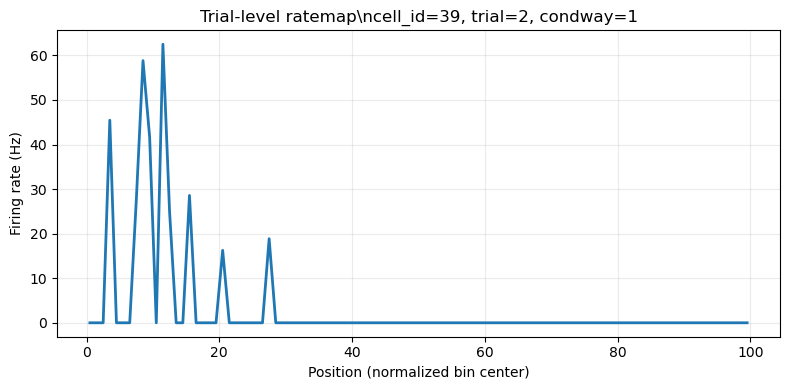

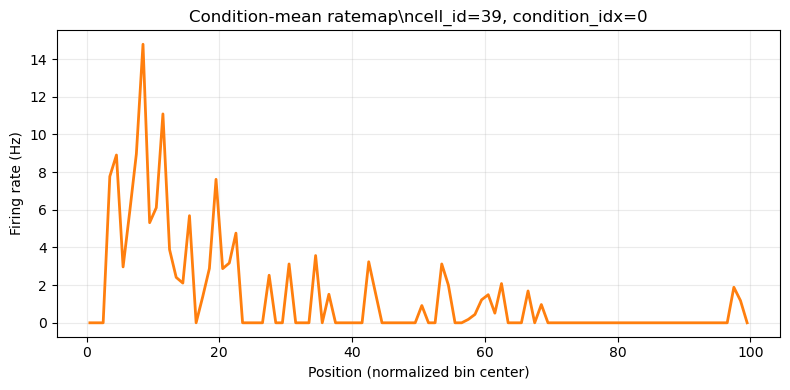

In [6]:
# Plot trial-level and condition-mean ratemaps in separate figures
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xbin_centers, fr_tx[u, t], lw=2)
ax.set_title(f'Trial-level ratemap\\ncell_id={cell_id}, trial={t}, condway={condway_trial}')
ax.set_xlabel('Position (normalized bin center)')
ax.set_ylabel('Firing rate (Hz)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xbin_centers, fr_cx[u, c], lw=2, color='tab:orange')
ax.set_title(f'Condition-mean ratemap\\ncell_id={cell_id}, condition_idx={c}')
ax.set_xlabel('Position (normalized bin center)')
ax.set_ylabel('Firing rate (Hz)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


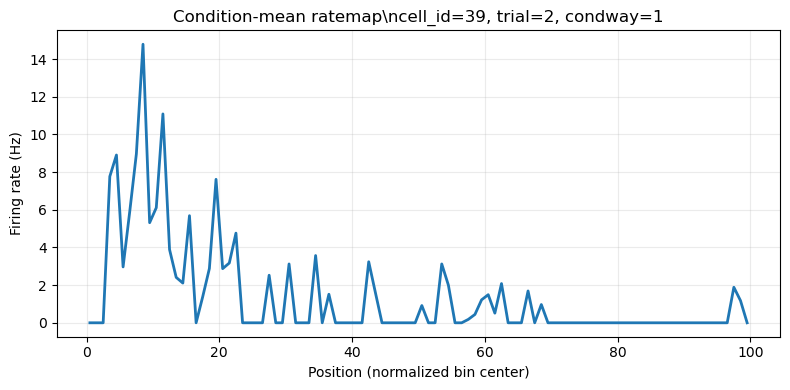

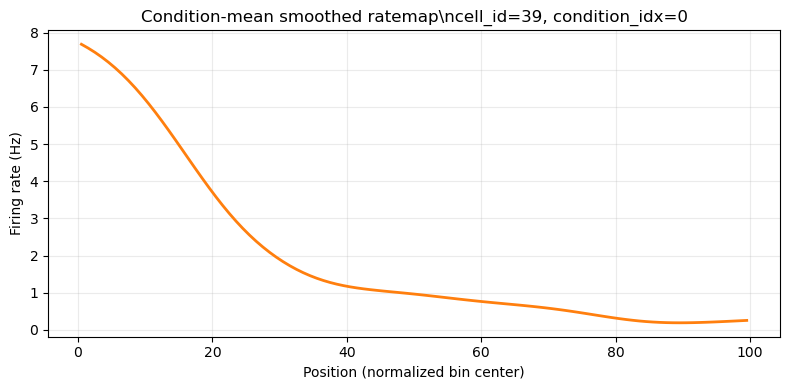

In [7]:
# Plot trial-level and condition-mean ratemaps in separate figures
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xbin_centers, fr_cx[u, c], lw=2)
ax.set_title(f'Condition-mean ratemap\\ncell_id={cell_id}, trial={t}, condway={condway_trial}')
ax.set_xlabel('Position (normalized bin center)')
ax.set_ylabel('Firing rate (Hz)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xbin_centers, fr_s_cx[u, c], lw=2, color='tab:orange')
ax.set_title(f'Condition-mean smoothed ratemap\\ncell_id={cell_id}, condition_idx={c}')
ax.set_xlabel('Position (normalized bin center)')
ax.set_ylabel('Firing rate (Hz)')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [8]:
param_keys = [
    'session_id',
    'source_allcel_npz',
    'source_traj_npz',
    'freq_spike_hz',
    'freq_behavior_hz',
    'normalize_x_to_100',
    'xbin_rem',
    'smooth_sigma_bins',
    'min_speed',
    'n_cells',
    'n_trials',
    'n_bins',
    'nb_cond',
]

param_table = pd.DataFrame({'parameter': param_keys, 'value': [meta.get(k, None) for k in param_keys]})
param_table


,parameter,value
0,session_id,VS64_2023-02-14_18-04-10
1,source_allcel_npz,data\interim\VS64\2023-02-14\VS64_2023-02-14_1...
2,source_traj_npz,data\interim\VS64\2023-02-14\VS64_2023-02-14_1...
3,freq_spike_hz,25000.0
4,freq_behavior_hz,1000.0
5,normalize_x_to_100,True
6,xbin_rem,0
7,smooth_sigma_bins,10.0
8,min_speed,2.0
9,n_cells,14


In [9]:
print(json.dumps(meta, indent=2))


{
  "session_id": "VS64_2023-02-14_18-04-10",
  "source_allcel_npz": "data\\interim\\VS64\\2023-02-14\\VS64_2023-02-14_18-04-10_allcel.npz",
  "source_traj_npz": "data\\interim\\VS64\\2023-02-14\\VS64_2023-02-14_18-04-10_trajdata.npz",
  "freq_spike_hz": 25000.0,
  "freq_behavior_hz": 1000.0,
  "normalize_x_to_100": true,
  "xbin_rem": 0,
  "smooth_sigma_bins": 10.0,
  "min_speed": 2.0,
  "n_cells": 14,
  "n_trials": 20,
  "n_bins": 100,
  "nb_cond": 2
}


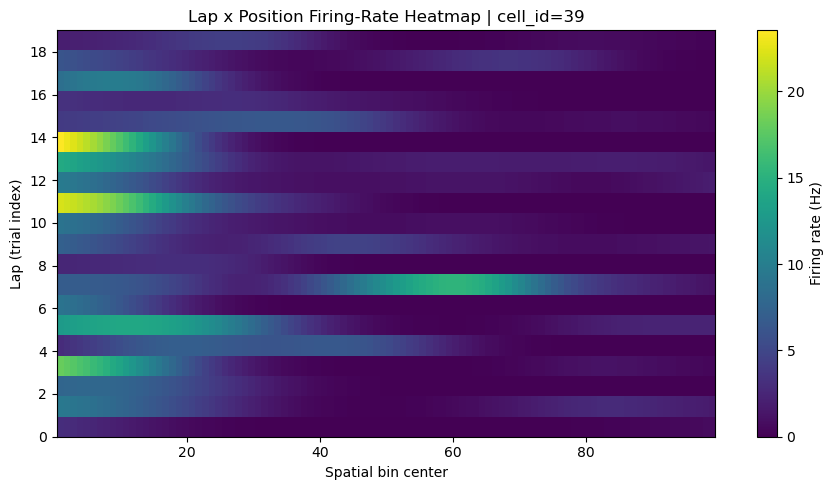

In [10]:
# Heatmap: firing rate by lap (y) and spatial bin (x) for the selected random cell
heat = fr_s_tx[u]  # shape: (n_trials, n_bins)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    heat,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[xbin_centers[0], xbin_centers[-1], 0, heat.shape[0] - 1],
    cmap='viridis',
)
n_laps = heat.shape[0]
step = max(1, n_laps // 10)  # avoid too many labels
ax.set_yticks(np.arange(0, n_laps, step))
ax.set_yticklabels(np.arange(0, n_laps, step).astype(int))

ax.set_xlabel('Spatial bin center')
ax.set_ylabel('Lap (trial index)')
ax.set_title(f'Lap x Position Firing-Rate Heatmap | cell_id={cell_id}')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Firing rate (Hz)')
plt.tight_layout()


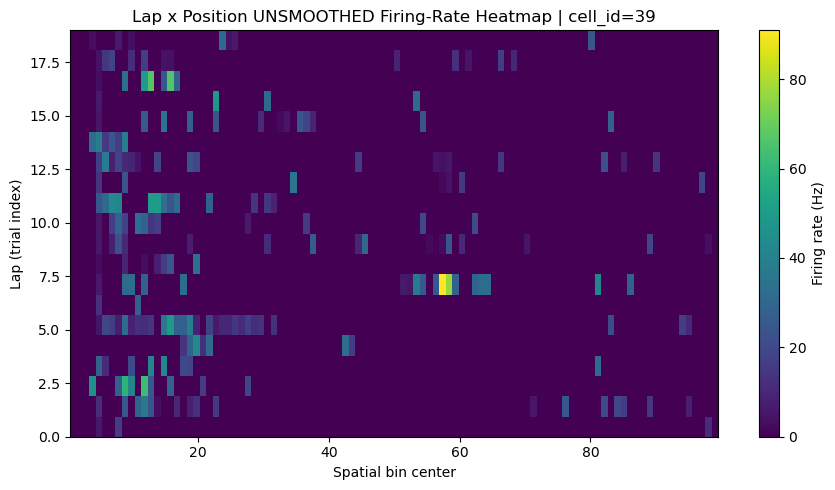

In [11]:
with np.load(rmap_path, allow_pickle=False) as z:
    fr_tx = z["rmap__fr_tx_ux"].astype(np.float64)
# Heatmap: UNSMOOTHED firing rate by lap (y) and spatial bin (x)
heat = fr_tx[u]  # shape: (n_trials, n_bins)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(
    heat,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    extent=[xbin_centers[0], xbin_centers[-1], 0, heat.shape[0] - 1],
    cmap='viridis',
)

ax.set_xlabel('Spatial bin center')
ax.set_ylabel('Lap (trial index)')
ax.set_title(f'Lap x Position UNSMOOTHED Firing-Rate Heatmap | cell_id={cell_id}')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Firing rate (Hz)')
plt.tight_layout()


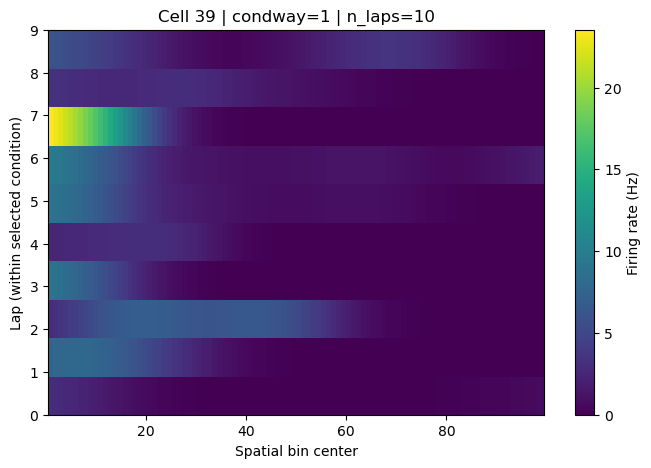

In [12]:
# pick one cell and one condition-direction (condway is 1-based)
u = 0
target_condway = 1  # e.g. 1,2,3,...

lap_idx = np.where(idcond_t == target_condway)[0]
heat = fr_s_tx[u, lap_idx, :]  # (n_laps_in_condition, n_bins)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    heat,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[xbin_centers[0], xbin_centers[-1], 0, heat.shape[0] - 1],
)
ax.set_xlabel("Spatial bin center")
ax.set_ylabel("Lap (within selected condition)")
ax.set_title(f"Cell {cell_ids[u]} | condway={target_condway} | n_laps={heat.shape[0]}")
fig.colorbar(im, ax=ax, label="Firing rate (Hz)")
plt.show()
